## Preparing the data for YOLO

* YOLO needs one txt file per image, and one line per bounding box. With this format: class_id ,x_center, y_center, width, height
* All the lengths and coordinates need to be normalized

In [ ]:
class_mapping = {
    "RBC": 0,
    "WBC": 1,
    "Platelets": 2
}

In [ ]:
import os
import shutil
import random
import cv2

### Shuffle and split the dataset into training and validation sets and put them in their folders

In [ ]:
source_images_dir = "images"
dataset_root = "dataset"

In [ ]:
#get all the image file names
all_filenames = [f for f in os.listdir(source_images_dir)]

random.seed(42) # For reproducibility of results
random.shuffle(all_filenames)

#split by index
split_index = int(len(all_filenames) * 0.8)
train_files = all_filenames[:split_index]
val_files = all_filenames[split_index:]

#achieve the actual split by copying images to their
for filename in train_files:
    src = os.path.join(source_images_dir, filename)
    dst = os.path.join(dataset_root, "train", "images", filename)
    shutil.copy(src, dst)

for filename in val_files:
    src = os.path.join(source_images_dir, filename)
    dst = os.path.join(dataset_root, "val", "images", filename)
    shutil.copy(src, dst)

### Read the bounding box annotations from CSV and convert to YOLO. Then split them.

In [ ]:
with open('data.csv', 'r') as f:
    for line in f:
        #read the line
        (filename, class_name, x1, y1, x2, y2) = line.strip().split(',')

        #for splitting
        if filename in train_files:
            split_folder = "train"
        else:
            split_folder = "val"

        class_id = class_mapping[class_name]
        
        width = int(x2) - int(x1)
        height = int(y2) - int(y1)
        
        x_center = int(x1) + width / 2
        y_center = int(y1) + height / 2
        
        #normalizing
        img = cv2.imread(f"images/{filename}")
        img_height, img_width = img.shape[:2]
        x_center /= img_width
        y_center /= img_height
        width /= img_width
        height /= img_height
        
        #save the new labels file with the same name of the image file
        txt_filename = filename.rsplit('.', 1)[0] + ".txt"
        dst_txt_path = os.path.join(dataset_root, split_folder, "labels", txt_filename)

        with open(dst_txt_path, 'a') as out_f:
            out_f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

### Train on YOLOv8 model

In [4]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model.train(
    data='dataset/data.yaml', # the data.yaml file contains details about the path to train and val folders, and the number and names of classes
    epochs=15,
    imgsz=640,
    project='blood_cell_project',
    name='yolov8_run',
)

metrics = model.val()
print(f"mAP50: {metrics.box.map50}")

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_run2, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [ ]:
import matplotlib.pyplot as plt
import glob


image 1/1 /root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/val/images/BloodImage_00165.jpg: 480x640 19 RBCs, 1 WBC, 108.9ms
Speed: 2.1ms preprocess, 108.9ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)


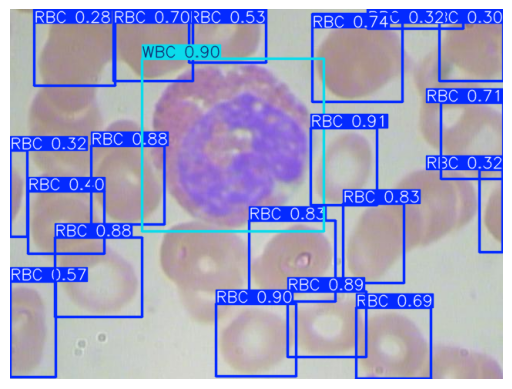

Saved prediction_sample.jpg


In [ ]:
#load the best model
model = YOLO('/blood_cell_project/yolov8_run/weights/best.pt')

#pick an image from the validation set
val_images = glob.glob('dataset/val/images/*.jpg') 
test_img = val_images[random.randint(0, len(val_images))]

results = model.predict(test_img)

#plot the result
for result in results:
    im_array = result.plot()
    plt.imshow(im_array[..., ::-1]) #BGR to RGB
    plt.axis('off')
    plt.show()